<a href="https://colab.research.google.com/github/pj8995/PredicaoDadosObesidade/blob/main/Pos_Predi%C3%A7ao_Dados_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

sns.set_theme(style="whitegrid")

In [ ]:
print("="*60)
print("1. VISÃO GERAL DO DATASET E ATRIBUTOS")
print("="*60)

df_train = pd.read_csv('/train.csv')
df_test = pd.read_csv('/test.csv')

print(f"Dimensões do Dataset de Treino: {df_train.shape[0]} linhas e {df_train.shape[1]} colunas.")
print(f"Dimensões do Dataset de Teste:  {df_test.shape[0]} linhas e {df_test.shape[1]} colunas.\n")

if 'id' in df_test.columns:
    test_ids = df_test['id']
elif 'ID' in df_test.columns:
    test_ids = df_test['ID']
else:
    test_ids = range(len(df_test))

num_cols = df_train.select_dtypes(include=[np.number]).columns.drop(['id', 'ID'], errors='ignore').tolist()
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.drop(['NObeyesdad'], errors='ignore').tolist()

print(f"Variáveis Numéricas ({len(num_cols)}): {num_cols}")
print(f"Variáveis Categóricas ({len(cat_cols)}): {cat_cols}\n")

df_train = df_train.drop(columns=['id', 'ID'], errors='ignore')
df_test = df_test.drop(columns=['id', 'ID'], errors='ignore')

1. VISÃO GERAL DO DATASET E ATRIBUTOS
Dimensões do Dataset de Treino: 20758 linhas e 18 colunas.
Dimensões do Dataset de Teste:  13840 linhas e 17 colunas.

Variáveis Numéricas (8): ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Variáveis Categóricas (8): ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']



In [16]:
print("="*60)
print("2. ANÁLISE DESCRITIVA E TRATAMENTO DE RUÍDOS (OUTLIERS)")
print("="*60)

# ===== ANTES DA LIMPEZA =====
print("\n📊 Tabela Descritiva ANTES da Limpeza:")
print("-" * 80)
print(df_train[num_cols].describe().round(2))

linhas_antes = df_train.shape[0]

# ===== APLICANDO FILTROS =====
df_train = df_train[(df_train['Age'] < 120) & (df_train['Height'] < 2.5) & (df_train['Weight'] < 300)]
df_train = df_train.reset_index(drop=True)
print(f"\n❌ Registros aberrantes removidos no conjunto de Treino: {linhas_antes - df_train.shape[0]}")

# ===== VERIFICANDO DUPLICATAS =====
total_duplicados = df_train.duplicated().sum()
print(f"❌ Número de linhas duplicadas encontradas: {total_duplicados}")

if total_duplicados > 0:
    print(f"🗑️  Removendo {total_duplicados} linhas duplicadas para proteger a validação...")
    df_train = df_train.drop_duplicates().reset_index(drop=True)
else:
    print("✅ Excelente! Sem dados duplicados após a limpeza de ruídos.")

# ===== DEPOIS DA LIMPEZA =====
print("\n📊 Tabela Descritiva DEPOIS da Limpeza:")
print("-" * 80)
print(df_train[num_cols].describe().round(2))

print("\n" + "="*80)
print(f"✅ Resumo da Limpeza: {linhas_antes} → {df_train.shape[0]} registros ({df_train.shape[0]/linhas_antes*100:.1f}%)")
print("="*80 + "\n")

2. ANÁLISE DESCRITIVA E TRATAMENTO DE RUÍDOS (OUTLIERS)

📊 Tabela Descritiva ANTES da Limpeza:
--------------------------------------------------------------------------------
            Age    Height    Weight      FCVC       NCP      CH2O       FAF  \
count  20758.00  20758.00  20758.00  20758.00  20758.00  20758.00  20758.00   
mean      23.84      1.70     87.89      2.45      2.76      2.03      0.98   
std        5.69      0.09     26.38      0.53      0.71      0.61      0.84   
min       14.00      1.45     39.00      1.00      1.00      1.00      0.00   
25%       20.00      1.63     66.00      2.00      3.00      1.79      0.01   
50%       22.82      1.70     84.06      2.39      3.00      2.00      1.00   
75%       26.00      1.76    111.60      3.00      3.00      2.55      1.59   
max       61.00      1.98    165.06      3.00      4.00      3.00      3.00   

            TUE  
count  20758.00  
mean       0.62  
std        0.60  
min        0.00  
25%        0.00  
50% 

In [ ]:
def aplicar_engenharia_features(df):
    df_out = df.copy()
    df_out['IMC'] = df_out['Weight'] / (df_out['Height'] ** 2)
    df_out['Agua_por_Peso'] = df_out['CH2O'] / df_out['Weight']
    df_out['Age_Round'] = np.round(df_out['Age'])
    df_out['Atividade_vs_Tela'] = df_out['FAF'] - df_out['TUE']
    return df_out

df_train = aplicar_engenharia_features(df_train)
df_test = aplicar_engenharia_features(df_test)

print("✓ Feature Engineering concluído!")

✓ Feature Engineering concluído!


3. DISTRIBUIÇÃO DOS DADOS E INSIGHTS GRÁFICOS


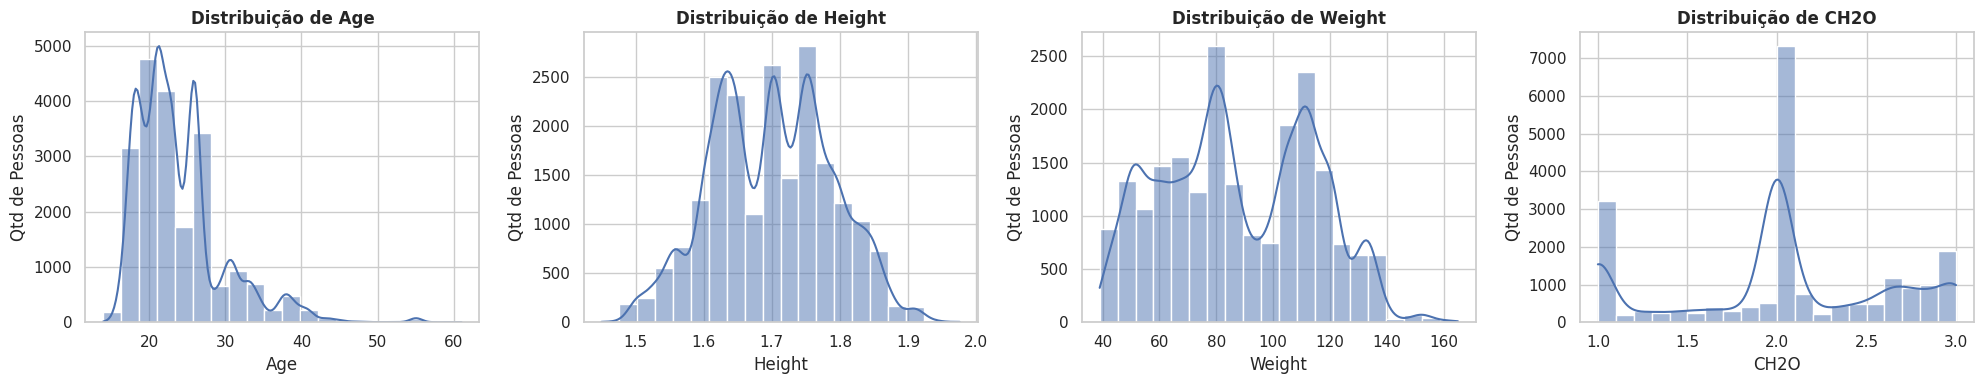

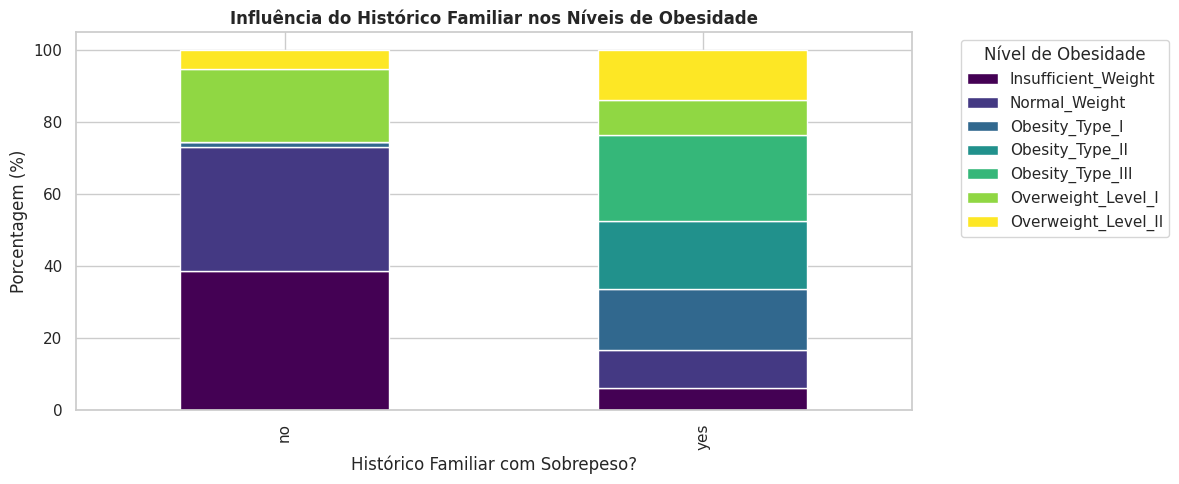

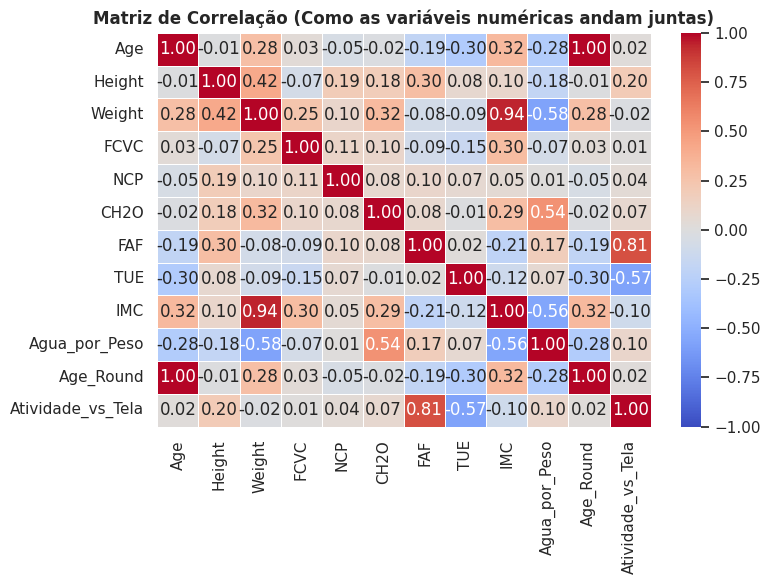

In [13]:
print("="*60)
print("3. DISTRIBUIÇÃO DOS DADOS E INSIGHTS GRÁFICOS")
print("="*60)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(['Age', 'Height', 'Weight', 'CH2O']):
    sns.histplot(df_train[col], ax=axes[i], color='#4C72B0', kde=True, bins=20)
    axes[i].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Qtd de Pessoas')
plt.tight_layout()
plt.show()

print("\n")

historico_obesidade = pd.crosstab(df_train['family_history_with_overweight'], df_train['NObeyesdad'], normalize='index') * 100
historico_obesidade.plot(kind='bar', stacked=True, figsize=(12, 5), cmap='viridis')
plt.title('Influência do Histórico Familiar nos Níveis de Obesidade', fontsize=12, fontweight='bold')
plt.xlabel('Histórico Familiar com Sobrepeso?')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Nível de Obesidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n")

plt.figure(figsize=(8, 6))
df_num = df_train.select_dtypes(include=[np.number])
corr = df_num.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação (Como as variáveis numéricas andam juntas)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_532/2470594085.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_plot, x='Categoria_Peso', y='Agua_Litros', ax=axes[0, 1], palette='Blues')
/tmp/ipykernel_532/2470594085.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_plot, x='Categoria_Peso', y='Atividade_vs_Tela', ax=axes[1, 1], palette='Set2')


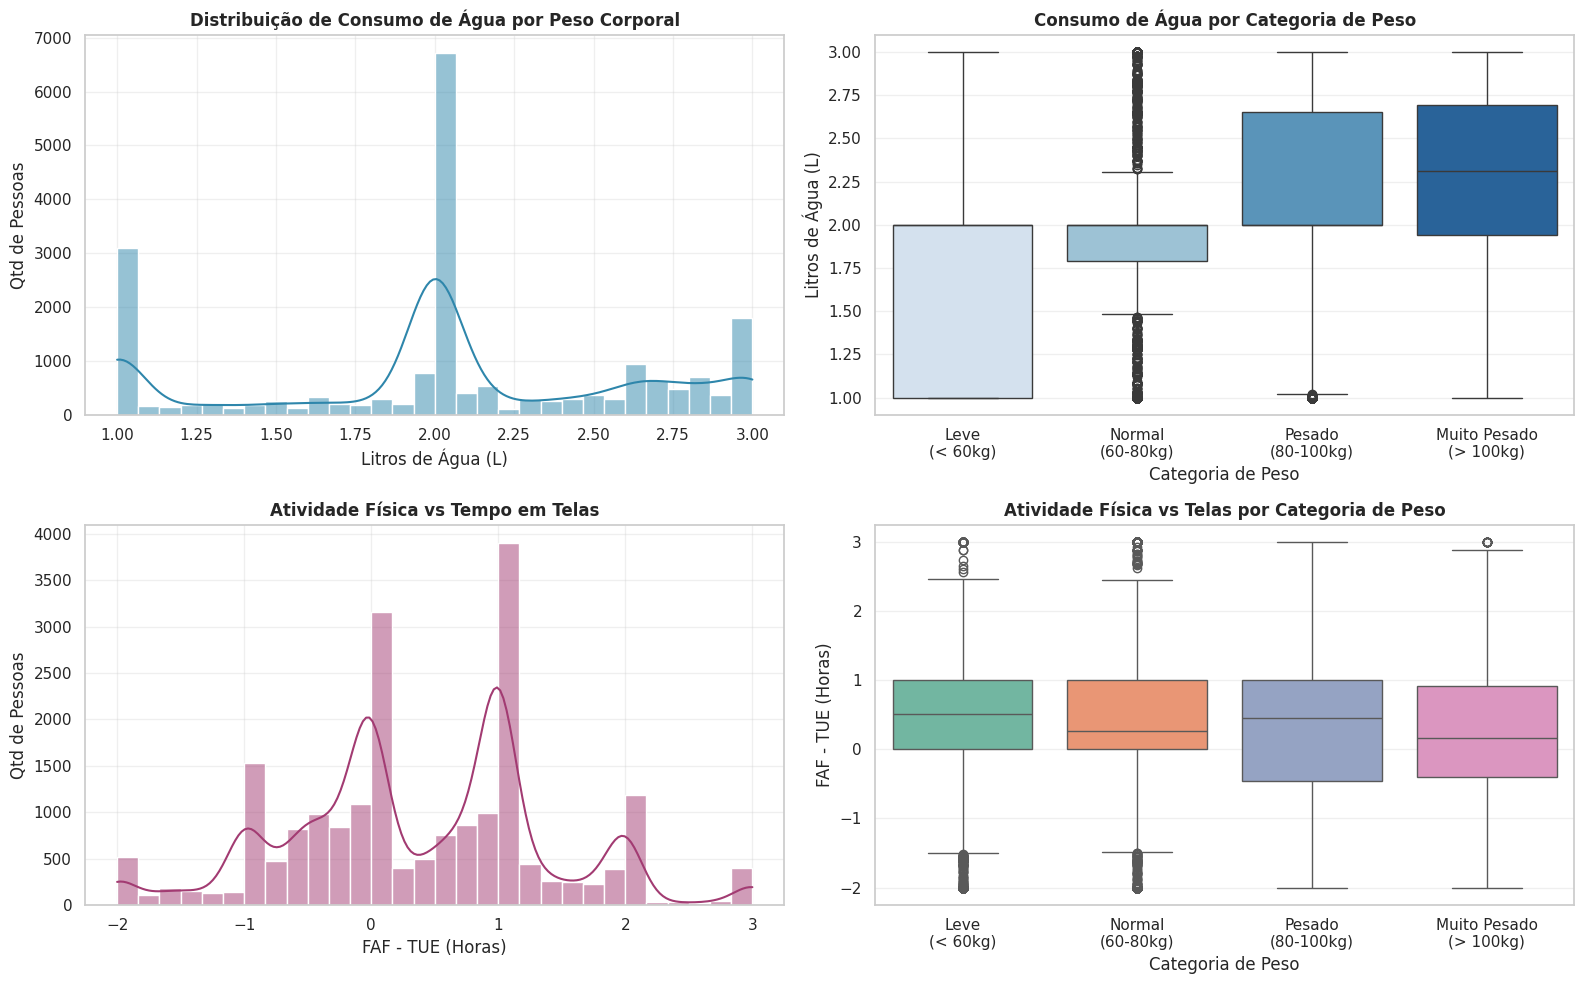

In [15]:
# ===== NOVO: Gráficos das Features Engineerizadas =====
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ===== GRÁFICO 1: Água por Peso (Histograma simples) =====
agua_litros = df_train['Agua_por_Peso'] * df_train['Weight']
sns.histplot(agua_litros, ax=axes[0, 0], color='#2E86AB', kde=True, bins=30)
axes[0, 0].set_title('Distribuição de Consumo de Água por Peso Corporal', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Litros de Água (L)')
axes[0, 0].set_ylabel('Qtd de Pessoas')
axes[0, 0].grid(alpha=0.3)

# ===== GRÁFICO 2: Água por Peso (Box plot por categoria) =====
df_train_plot = df_train.copy()
df_train_plot['Categoria_Peso'] = pd.cut(df_train_plot['Weight'],
                                          bins=[0, 60, 80, 100, 200],
                                          labels=['Leve\n(< 60kg)', 'Normal\n(60-80kg)', 'Pesado\n(80-100kg)', 'Muito Pesado\n(> 100kg)'])
df_train_plot['Agua_Litros'] = agua_litros

sns.boxplot(data=df_train_plot, x='Categoria_Peso', y='Agua_Litros', ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Consumo de Água por Categoria de Peso', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Categoria de Peso')
axes[0, 1].set_ylabel('Litros de Água (L)')
axes[0, 1].grid(alpha=0.3, axis='y')

# ===== GRÁFICO 3: Atividade vs Tela (Histograma simples) =====
sns.histplot(df_train['Atividade_vs_Tela'], ax=axes[1, 0], color='#A23B72', kde=True, bins=30)
axes[1, 0].set_title('Atividade Física vs Tempo em Telas', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('FAF - TUE (Horas)')
axes[1, 0].set_ylabel('Qtd de Pessoas')
axes[1, 0].grid(alpha=0.3)

# ===== GRÁFICO 4: Atividade vs Tela (Box plot por categoria de peso) =====
sns.boxplot(data=df_train_plot, x='Categoria_Peso', y='Atividade_vs_Tela', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Atividade Física vs Telas por Categoria de Peso', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Categoria de Peso')
axes[1, 1].set_ylabel('FAF - TUE (Horas)')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n")

In [ ]:
X = df_train.drop(columns=['NObeyesdad'])
y = df_train['NObeyesdad']

# Converter colunas categóricas
for col in cat_cols:
    X[col] = X[col].astype('category')
    df_test[col] = df_test[col].astype('category')

# Codificar target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split treino/validação
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Treino: {X_train.shape} | Validação: {X_val.shape}")

Treino: (16606, 20) | Validação: (4152, 20)


In [ ]:
print("="*60)
print("4. TREINAMENTO DO MODELO OTIMIZADO (LIGHTGBM)")
print("="*60)

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=7,
    random_state=42,
    n_estimators=600,
    learning_rate=0.04,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)
print("✓ Modelo treinado com sucesso!")

4. TREINAMENTO DO MODELO OTIMIZADO (LIGHTGBM)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2858
[LightGBM] [Info] Number of data points in the train set: 16606, number of used features: 20
[LightGBM] [Info] Start training from score -2.107657
[LightGBM] [Info] Start training from score -1.907572
[LightGBM] [Info] Start training from score -1.964755
[LightGBM] [Info] Start training from score -1.855022
[LightGBM] [Info] Start training from score -1.635117
[LightGBM] [Info] Start training from score -2.146046
[LightGBM] [Info] Start training from score -2.107657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [ ]:
print("="*60)
print("5. MÉTRICAS DE AVALIAÇÃO DO MODELO")
print("="*60)

y_pred = model.predict(X_val)
acuracia = accuracy_score(y_val, y_pred)

print(f"ACURÁCIA: {acuracia:.4f}\n")
print("Relatório detalhado de Classificação:\n")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

5. MÉTRICAS DE AVALIAÇÃO DO MODELO
ACURÁCIA: 0.9078

Relatório detalhado de Classificação:

                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.95      0.94       505
      Normal_Weight       0.88      0.90      0.89       617
     Obesity_Type_I       0.87      0.89      0.88       582
    Obesity_Type_II       0.97      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.82      0.78      0.80       485
Overweight_Level_II       0.81      0.80      0.80       504

           accuracy                           0.91      4152
          macro avg       0.90      0.90      0.90      4152
       weighted avg       0.91      0.91      0.91      4152



In [ ]:
print("="*60)
print("6. APLICAÇÃO NA BASE DE TESTES E EXPORTAÇÃO KAGGLE")
print("="*60)

preds_test = model.predict(df_test)
preds_test_labels = label_encoder.inverse_transform(preds_test)

submissao = pd.DataFrame({
    'id': test_ids,
    'NObeyesdad': preds_test_labels
})

submissao.to_csv('submission.csv', index=False)
print("✓ Arquivo 'submission.csv' gerado com sucesso!")
print(submissao.head())

6. APLICAÇÃO NA BASE DE TESTES E EXPORTAÇÃO KAGGLE
✓ Arquivo 'submission.csv' gerado com sucesso!
      id          NObeyesdad
0  20758     Obesity_Type_II
1  20759  Overweight_Level_I
2  20760    Obesity_Type_III
3  20761      Obesity_Type_I
4  20762    Obesity_Type_III
